# Task 2.3 — Hyperparameter Experimentation
**Week 2 | Skillset Go EduTech AI/ML Track**

Controlled experiments on the CNN from Task 2.2. A **baseline** configuration is fixed (Adam, lr=1e-3, batch=64,
20 epochs) and **one factor at a time** is varied — optimizer, learning rate, batch size, epochs — with the same
seed and the same data split for every run, so differences are attributable to the changed factor.
Configurations are compared on **validation accuracy**; test accuracy is reported alongside for the final picture.

In [1]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt, time
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42); np.random.seed(42)

digits = load_digits()
images = (digits.images / 16.0).astype('float32')       # 1797 x 8 x 8, scaled to [0,1]
labels = digits.target.astype('int64')

X_tr, X_tmp, y_tr, y_tmp = train_test_split(images, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(1)        # add channel dim -> (N,1,8,8)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class SimpleCNN(nn.Module):
    def __init__(self, c1=16, c2=32, p_drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, c1, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 8x8 -> 4x4
            nn.Conv2d(c1, c2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 4x4 -> 2x2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(c2 * 2 * 2, 64), nn.ReLU(), nn.Dropout(p_drop), nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def evaluate(model, loader):
    model.eval(); correct, total, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            loss_sum += crit(out, yb).item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item(); total += len(yb)
    return loss_sum / total, correct / total

import pandas as pd

def run_experiment(factor, optimizer='Adam', lr=1e-3, batch_size=64, epochs=20, seed=0):
    torch.manual_seed(seed)
    tr = DataLoader(ImageDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True,
                    generator=torch.Generator().manual_seed(seed))
    va = DataLoader(ImageDataset(X_val, y_val), batch_size=256)
    te = DataLoader(ImageDataset(X_te, y_te), batch_size=256)
    model = SimpleCNN()
    opts = {
        'SGD':          lambda p: torch.optim.SGD(p, lr=lr),
        'SGD+Momentum': lambda p: torch.optim.SGD(p, lr=lr, momentum=0.9),
        'Adam':         lambda p: torch.optim.Adam(p, lr=lr),
        'RMSprop':      lambda p: torch.optim.RMSprop(p, lr=lr),
    }
    opt, crit = opts[optimizer](model.parameters()), nn.CrossEntropyLoss()
    t0 = time.time(); last_train_loss = None
    for _ in range(epochs):
        model.train(); s = 0.0
        for xb, yb in tr:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step(); s += loss.item() * len(yb)
        last_train_loss = s / len(y_tr)
    _, val_acc = evaluate(model, va); _, test_acc = evaluate(model, te)
    return dict(factor=factor, optimizer=optimizer, lr=lr, batch_size=batch_size, epochs=epochs,
                final_train_loss=round(last_train_loss, 4), val_acc=round(val_acc, 4),
                test_acc=round(test_acc, 4), time_s=round(time.time() - t0, 1))

## Experiment grid (one factor varied at a time)

In [2]:
runs = []
runs.append(run_experiment('baseline'))
for o in ['SGD', 'SGD+Momentum', 'RMSprop']:
    runs.append(run_experiment('optimizer', optimizer=o))
# SGD-family optimizers need a larger learning rate than Adam, so give them a fair (tuned) setting too
runs.append(run_experiment('optimizer', optimizer='SGD', lr=0.1))
runs.append(run_experiment('optimizer', optimizer='SGD+Momentum', lr=0.01))
for lr in [1e-4, 1e-2, 1e-1]:
    runs.append(run_experiment('learning rate', lr=lr))
for bs in [16, 32, 128]:
    runs.append(run_experiment('batch size', batch_size=bs))
for ep in [5, 10, 40]:
    runs.append(run_experiment('epochs', epochs=ep))

log = pd.DataFrame(runs)
log.insert(0, 'run', range(1, len(log) + 1))
log.to_csv('experiment_log.csv', index=False)
print(f"{len(log)} runs completed")
log

15 runs completed


,run,factor,optimizer,lr,batch_size,epochs,final_train_loss,val_acc,test_acc,time_s
0,1,baseline,Adam,0.0010,64,20,0.1576,0.9519,0.9556,1.1
1,2,optimizer,SGD,0.0010,64,20,2.3054,0.1037,0.1037,0.9
2,3,optimizer,SGD+Momentum,0.0010,64,20,2.2889,0.1148,0.1185,0.9
3,4,optimizer,RMSprop,0.0010,64,20,0.1317,0.9259,0.9481,1.0
4,5,optimizer,SGD,0.1000,64,20,0.3091,0.8333,0.8815,0.9
5,6,optimizer,SGD+Momentum,0.0100,64,20,0.3345,0.9000,0.9148,1.0
6,7,learning rate,Adam,0.0001,64,20,1.9639,0.6778,0.7333,1.1
7,8,learning rate,Adam,0.0100,64,20,0.0133,0.9519,0.9704,1.1
8,9,learning rate,Adam,0.1000,64,20,1.1541,0.6630,0.6852,1.0
9,10,batch size,Adam,0.0010,16,20,0.0471,0.9593,0.9704,2.8


## Comparison table (sorted by validation accuracy)

In [3]:
table = log.sort_values(['val_acc', 'final_train_loss'], ascending=[False, True]).reset_index(drop=True)
table.to_csv('experiment_comparison_table.csv', index=False)
table

,run,factor,optimizer,lr,batch_size,epochs,final_train_loss,val_acc,test_acc,time_s
0,15,epochs,Adam,0.0010,64,40,0.0503,0.9741,0.9815,2.2
1,10,batch size,Adam,0.0010,16,20,0.0471,0.9593,0.9704,2.8
2,11,batch size,Adam,0.0010,32,20,0.1014,0.9593,0.9630,1.8
3,8,learning rate,Adam,0.0100,64,20,0.0133,0.9519,0.9704,1.1
4,1,baseline,Adam,0.0010,64,20,0.1576,0.9519,0.9556,1.1
5,4,optimizer,RMSprop,0.0010,64,20,0.1317,0.9259,0.9481,1.0
6,12,batch size,Adam,0.0010,128,20,0.2875,0.9148,0.9222,0.8
7,6,optimizer,SGD+Momentum,0.0100,64,20,0.3345,0.9000,0.9148,1.0
8,14,epochs,Adam,0.0010,64,10,0.3891,0.8667,0.9074,0.6
9,5,optimizer,SGD,0.1000,64,20,0.3091,0.8333,0.8815,0.9


## Visual comparison

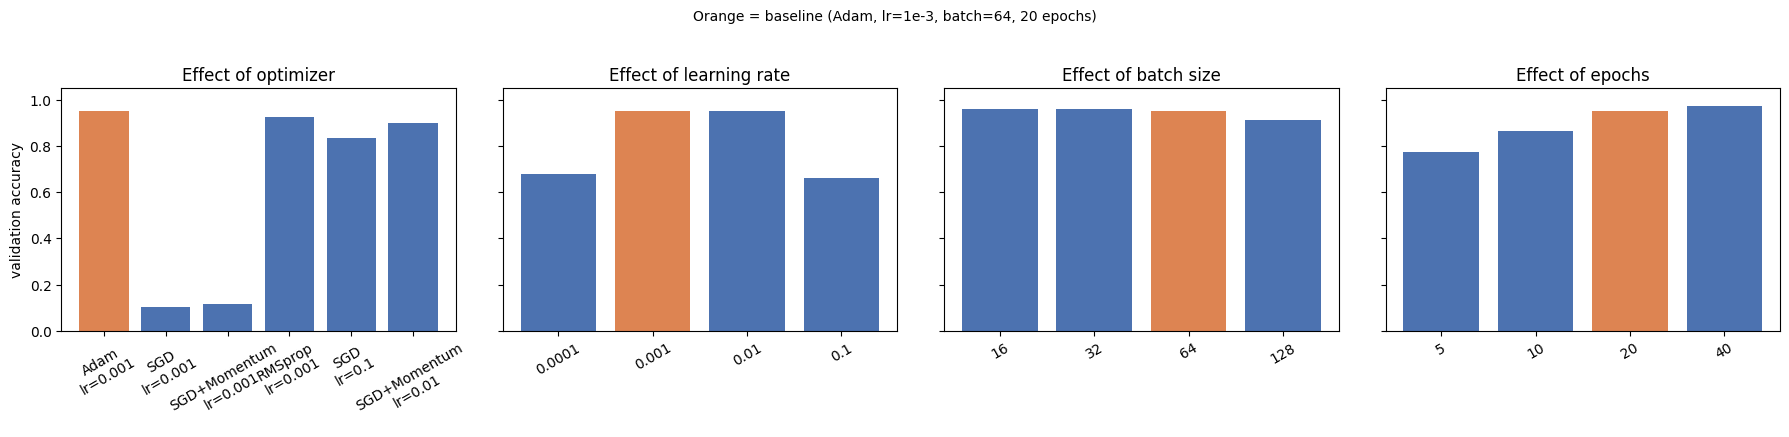

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
base = log[log.factor == 'baseline'].iloc[0]
for ax, (factor, col) in zip(axes, [('optimizer', 'optimizer'), ('learning rate', 'lr'),
                                    ('batch size', 'batch_size'), ('epochs', 'epochs')]):
    sub = pd.concat([log[log.factor == 'baseline'], log[log.factor == factor]])
    sub = sub.assign(label=sub[col].astype(str) + (('\nlr=' + sub.lr.astype(str)) if factor == 'optimizer' else ''))
    sub = sub.drop_duplicates('label')
    if factor != 'optimizer':
        sub = sub.sort_values(col)
    ax.bar(sub.label, sub.val_acc, color=['#DD8452' if f == 'baseline' else '#4C72B0' for f in sub.factor])
    ax.set_title(f'Effect of {factor}'); ax.set_ylim(0, 1.05); ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('validation accuracy')
plt.suptitle('Orange = baseline (Adam, lr=1e-3, batch=64, 20 epochs)', y=1.03, fontsize=10)
plt.tight_layout(); plt.savefig('hyperparameter_comparison.png', dpi=110, bbox_inches='tight'); plt.show()

## Findings

In [5]:
best = table.iloc[0]; worst = table.iloc[-1]
print(f"Baseline           : val acc {base.val_acc:.4f} | test acc {base.test_acc:.4f}")
print(f"Best configuration : {best.optimizer}, lr={best.lr}, batch={best.batch_size}, epochs={best.epochs} "
      f"-> val acc {best.val_acc:.4f}, test acc {best.test_acc:.4f}")
print(f"Worst configuration: {worst.optimizer}, lr={worst.lr}, batch={worst.batch_size}, epochs={worst.epochs} "
      f"-> val acc {worst.val_acc:.4f}, test acc {worst.test_acc:.4f}")
for factor in ['optimizer', 'learning rate', 'batch size', 'epochs']:
    s = log[log.factor.isin([factor, 'baseline'])]
    print(f"Spread in val acc when varying {factor:13s}: {s.val_acc.min():.4f} - {s.val_acc.max():.4f}")

Baseline           : val acc 0.9519 | test acc 0.9556
Best configuration : Adam, lr=0.001, batch=64, epochs=40 -> val acc 0.9741, test acc 0.9815
Worst configuration: SGD, lr=0.001, batch=64, epochs=20 -> val acc 0.1037, test acc 0.1037
Spread in val acc when varying optimizer    : 0.1037 - 0.9519
Spread in val acc when varying learning rate: 0.6630 - 0.9519
Spread in val acc when varying batch size   : 0.9148 - 0.9593
Spread in val acc when varying epochs       : 0.7741 - 0.9741
